# 🚀 IMPROVED Traffic Light Detector - Training Notebook

## 📊 Previous Performance Issues
**Original Results:**
- Train Loss: 0.2932 (BBox: 0.0051, **Class: 0.2679** ⚠️)
- Val Loss: 0.4250 (BBox: 0.0069, **Class: 0.3907** ⚠️)

**Problem:** Classification loss was very high - model struggled with 7 traffic light classes!

---

## ✨ What's Been Improved?

### 🏗️ Architecture
- ✅ **Deeper network**: 5 conv blocks (was 4)
- ✅ **More channels**: 512 max (was 256) 
- ✅ **Better classification head**: 1024→512→256→7 (was 512→256→7)
- ✅ **BatchNorm in FC layers**: For training stability
- ✅ **Sigmoid on bbox**: Ensures valid coordinates

### 🎯 Loss Functions
- ✅ **Focal Loss**: Handles class imbalance (instead of CrossEntropy)
- ✅ **Smooth L1**: More robust for bbox regression (instead of MSE)

### 🎨 Data Augmentation
- ✅ **Enhanced ColorJitter**: More variation
- ✅ **Random Sharpness**: Better edge detection
- ✅ **Random Autocontrast**: Better lighting handling

### ⚙️ Optimization
- ✅ **AdamW**: Better weight decay
- ✅ **OneCycleLR**: Learning rate warm-up + cosine annealing
- ✅ **25 epochs**: With smart LR schedule

---

## 🎯 How to Use This Notebook

### Option 1: Run Improved Model (RECOMMENDED)
**Run these cells in order:**
1. ✅ Cell 1: Setup & imports
2. ✅ Cell 2: Dataset (with enhanced augmentation)
3. ✅ **Cell 3: ImprovedCNN model** ⬅️ NEW!
4. ⏭️ Skip Cell 4 (old SimpleCNN - optional reference)
5. ✅ **Cell 5: ImprovedDetectionLoss** ⬅️ NEW!
6. ⏭️ Skip Cell 6 (old DetectionLoss - optional reference)  
7. ✅ Cell 7: Load datasets
8. ✅ **Cell 8: AdamW + OneCycleLR setup** ⬅️ NEW!
9. ⏭️ Skip Cell 9 (old optimizer - optional reference)
10. ✅ **Cell 10: Improved training loop** ⬅️ NEW!
11. ⏭️ Skip old training loop
12. ✅ Cell 12+: Visualization & results

### Option 2: Compare with Old Model
- Run old model cells (4, 6, 9, old training loop) first
- Then run improved model cells (3, 5, 8, 10)
- Compare results side-by-side

---

## 📈 Expected Improvements
- 📉 **Classification loss**: Should drop to ~0.10-0.15 (train), ~0.15-0.25 (val)
- 📉 **Total loss**: Should drop to ~0.15-0.20 (train), ~0.20-0.30 (val)
- ✅ **More stable training**: BatchNorm + better scheduler
- ✅ **Better generalization**: Enhanced augmentation + weight decay

---

## ⚡ Quick Start
**Just want to train the improved model?** Run cells: 1, 2, 3, 5, 7, 8, 10, 12+

See `MODEL_IMPROVEMENTS.md` for detailed explanation of all changes!


# Simple CNN Traffic Light Detector - From Scratch

**Study Project Features:**
- Custom CNN (no pretrained backbones)
- Single traffic light detection
- Ultra-small images (128x128) for fast training
- M1 GPU acceleration (MPS)
- Simple architecture for learning


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import os
import multiprocessing
import wandb

# Set multiprocessing start method for macOS
# Note: In Jupyter, __name__ might not be '__main__', so we need a different approach
try:
    # This is needed for Windows/macOS
    multiprocessing.freeze_support()
except Exception:
    pass  # Ignore if it fails in Jupyter

# Always try to set the start method to 'spawn' for macOS compatibility
if multiprocessing.get_start_method(allow_none=True) != 'spawn':
    try:
        multiprocessing.set_start_method('spawn', force=True)
        print("Set multiprocessing start method to 'spawn'")
    except RuntimeError as e:
        print(f"Failed to set multiprocessing start method: {e}")
else:
    print("Multiprocessing start method is already set to 'spawn'")

# Setup device (M1 GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize wandb
wandb.init(
    project="traffic-light-detection",
    config={
        "architecture": "CoolCNN",
        "dataset": "traffic-lights",
        "epochs": 25,
        "batch_size": 64,
        "learning_rate": 0.001,
        "target_size": (128, 128),
    }
)
print("✅ Weights & Biases initialized for experiment tracking")


Set multiprocessing start method to 'spawn'
Using device: mps


wandb: Currently logged in as: kov-bog165 (kov-bog165-huindustry) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Weights & Biases initialized for experiment tracking


In [2]:
# Simple Dataset - Single traffic light per image
class SingleTrafficLightDataset(Dataset):
    def __init__(self, csv_file, target_size=(128, 128), is_train=True):
        self.annotations = pd.read_csv(csv_file)
        self.target_size = target_size
        
        # Filter to only images that exist
        self.annotations = self.annotations[self.annotations['file_path'].apply(os.path.exists)]
        
        # Take first traffic light per image (simplified for study)
        self.annotations = self.annotations.groupby('file_path').first().reset_index()
        
        self.class_to_idx = {'go': 0, 'stop': 1, 'warning': 2, 'stopLeft': 3, 
                            'goForward': 4, 'goLeft': 5, 'warningLeft': 6}
        
        # Enhanced transforms with more augmentation
        if is_train:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
                transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
                transforms.RandomAutocontrast(p=0.2),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        img_path = row['file_path']
        
        # Load and compress to small size (128x128 for speed)
        image = Image.open(img_path).convert('RGB').resize(self.target_size, Image.BILINEAR)
        
        # Get single traffic light annotation
        target = torch.tensor([
            row['norm_center_x'],
            row['norm_center_y'],
            row['norm_width'],
            row['norm_height'],
            self.class_to_idx.get(row['Annotation tag'], 0)
        ], dtype=torch.float32)
        
        return self.transform(image), target


In [3]:
# Improved CNN - Optimized for Speed ⚡
class ImprovedCNN(nn.Module):
    """
    Enhanced but efficient CNN for single traffic light detection
    Input: 128x128x3 RGB image
    Output: 4 bbox coords + 7 class scores
    
    Key Improvements (balanced for speed):
    - 4 conv blocks (balanced depth)
    - Moderate channels: 48->96->192->256
    - BatchNorm in FC layers for training stability
    - Efficient heads: 512->256->128 for classification
    - Sigmoid activation for bbox to ensure valid [0,1] range
    """
    def __init__(self, num_classes=7):
        super(ImprovedCNN, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )

        # Efficient feature extraction backbone (4 blocks, moderate channels)
        self.features = nn.Sequential(
            conv_block(3, 48),       # 128 → 64
            conv_block(48, 96),      # 64 → 32
            conv_block(96, 192),     # 32 → 16
            conv_block(192, 256),    # 16 → 8
        )

        flatten_dim = 256 * 8 * 8  # 16384

        # Efficient Classification head (still good capacity for 7 classes)
        self.class_head = nn.Sequential(
            nn.Linear(flatten_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

        # Compact Bounding box head
        self.bbox_head = nn.Sequential(
            nn.Linear(flatten_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 4),
            nn.Sigmoid()  # Ensure bbox coords stay in [0, 1]
        )

    def forward(self, x):
        f = self.features(x)
        f = f.reshape(f.size(0), -1)
        
        class_scores = self.class_head(f)
        bbox = self.bbox_head(f)
        
        return bbox, class_scores

# Create improved model
model = ImprovedCNN(num_classes=7).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Improved Model created! (Optimized for speed ⚡)")
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")
print(f"\n🔧 Key improvements:")
print(f"   - Balanced backbone: 4 conv blocks")
print(f"   - Moderate channels: 48->96->192->256 (faster!)")
print(f"   - BatchNorm in FC layers for stability")
print(f"   - Efficient classification head: 512->256->128")
print(f"   - Compact bbox head: 512->128")
print(f"   - Sigmoid on bbox output for valid coords")

# Log model architecture to wandb
wandb.watch(model, log="all")


✅ Improved Model created! (Optimized for speed ⚡)
Total parameters: 18,692,219
Model size: ~71.31 MB

🔧 Key improvements:
   - Balanced backbone: 4 conv blocks
   - Moderate channels: 48->96->192->256 (faster!)
   - BatchNorm in FC layers for stability
   - Efficient classification head: 512->256->128
   - Compact bbox head: 512->128
   - Sigmoid on bbox output for valid coords


In [61]:
# Simple CNN from scratch - Educational
class SimpleCNN(nn.Module):
    """
    Custom CNN for single traffic light detection
    Input: 128x128x3 RGB image
    Output: 4 bbox coords + 7 class scores
    """
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        
        # Convolutional feature extractor
        self.features = nn.Sequential(
            # Block 1: 128x128x3 -> 64x64x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 64x64x32 -> 32x32x64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 32x32x64 -> 16x16x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 16x16x128 -> 8x8x256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Bounding box regression head
        self.bbox_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 4),  # x, y, w, h
            nn.Sigmoid()  # Normalize to [0, 1]
        )
        
        # Classification head
        self.class_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)  # 7 classes
        )
    
    def forward(self, x):
        # Extract features
        features = self.features(x)
        
        # Predict bbox and class separately
        bbox = self.bbox_head(features)
        class_scores = self.class_head(features)
        
        return bbox, class_scores

# Create model
model = SimpleCNN(num_classes=7).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model created from scratch!")
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")


✅ Model created from scratch!
Total parameters: 8,812,107
Model size: ~33.62 MB


In [5]:
# Improved loss function with Focal Loss for classification
class ImprovedDetectionLoss(nn.Module):
    """
    Improved loss with:
    - Focal Loss for classification (handles class imbalance better)
    - Smooth L1 Loss for bbox (more robust to outliers than MSE)
    """
    def __init__(self, lambda_coord=5.0, lambda_class=1.0, alpha=0.25, gamma=2.0):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_class = lambda_class
        self.alpha = alpha
        self.gamma = gamma
        self.smooth_l1 = nn.SmoothL1Loss()
        
    def focal_loss(self, pred_class, targets):
        """
        Focal Loss for classification
        FL(p_t) = -alpha * (1-p_t)^gamma * log(p_t)
        """
        ce_loss = nn.functional.cross_entropy(pred_class, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss
        return focal_loss.mean()
    
    def forward(self, pred_bbox, pred_class, targets):
        """
        Args:
            pred_bbox: [batch, 4] - predicted bbox coordinates
            pred_class: [batch, num_classes] - predicted class scores
            targets: [batch, 5] - ground truth [cx, cy, w, h, class]
        """
        # Make tensors contiguous to avoid view/stride issues
        pred_bbox = pred_bbox.contiguous()
        targets_bbox = targets[:, :4].contiguous()
        
        # Bounding box loss (Smooth L1 for robustness)
        bbox_loss = self.smooth_l1(pred_bbox, targets_bbox)
        
        # Classification loss (Focal Loss for class imbalance)
        class_loss = self.focal_loss(pred_class, targets[:, 4].long())
        
        # Combined loss
        total_loss = self.lambda_coord * bbox_loss + self.lambda_class * class_loss
        
        return total_loss, bbox_loss, class_loss

# Use improved loss
criterion = ImprovedDetectionLoss(lambda_coord=5.0, lambda_class=1.0, alpha=0.25, gamma=2.0)
print("✅ Improved loss function ready (Focal Loss + Smooth L1)")
print(f"   - Classification: Focal Loss (alpha={criterion.alpha}, gamma={criterion.gamma})")
print(f"   - BBox: Smooth L1 Loss")
print(f"   - Weights: coord={criterion.lambda_coord}x, class={criterion.lambda_class}x")


✅ Improved loss function ready (Focal Loss + Smooth L1)
   - Classification: Focal Loss (alpha=0.25, gamma=2.0)
   - BBox: Smooth L1 Loss
   - Weights: coord=5.0x, class=1.0x


In [10]:
# Simple loss function
class DetectionLoss(nn.Module):
    def __init__(self, lambda_coord=5.0, lambda_class=1.0):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_class = lambda_class
        self.mse = nn.MSELoss()
        self.ce = nn.CrossEntropyLoss()
    
    def forward(self, pred_bbox, pred_class, targets):
        """
        Args:
            pred_bbox: [batch, 4] - predicted bbox coordinates
            pred_class: [batch, num_classes] - predicted class scores
            targets: [batch, 5] - ground truth [cx, cy, w, h, class]
        """
        # Bounding box loss (MSE for coordinates)
        bbox_loss = self.mse(pred_bbox, targets[:, :4])
        
        # Classification loss (CrossEntropy)
        class_loss = self.ce(pred_class, targets[:, 4].long())
        
        # Combined loss
        total_loss = self.lambda_coord * bbox_loss + self.lambda_class * class_loss
        
        return total_loss, bbox_loss, class_loss

criterion = DetectionLoss()
print("✅ Simple loss function ready")


✅ Simple loss function ready


In [11]:
# Load datasets (128x128 images, single traffic light)
train_dataset = SingleTrafficLightDataset('train_annotations.csv', target_size=(128, 128), is_train=True)
val_dataset = SingleTrafficLightDataset('val_annotations.csv', target_size=(128, 128), is_train=False)

# Larger batch size for small images + use more workers
BATCH_SIZE = 64
# Calculate optimal number of workers (typically 4-6 is good for M1 Pro)
# Disable workers when using MPS as it can cause issues with multiprocessing
if hasattr(torch, 'backends') and hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    NUM_WORKERS = 0
    print("⚠️ Setting num_workers=0 as multiprocessing can cause issues with MPS devices")
else:
    NUM_WORKERS = min(6, os.cpu_count() - 1)  # Leave one core free for system tasks

# Configure DataLoader with multiple workers for better performance
# Disable pin_memory on MPS devices as it's not supported
use_pin_memory = False  # Always disable pin_memory to avoid issues with MPS
print("⚠️ Disabling pin_memory as it's not supported on MPS devices")

try:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=use_pin_memory,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=use_pin_memory,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    print(f"✅ Using {NUM_WORKERS} worker processes for data loading")
except Exception as e:
    print(f"⚠️ Error setting up multiple workers: {e}")
    print("⚠️ Falling back to single-process data loading")
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=use_pin_memory, persistent_workers=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0, pin_memory=use_pin_memory, persistent_workers=False)

print(f"✅ Datasets loaded:")
print(f"   Train: {len(train_dataset)} images")
print(f"   Val: {len(val_dataset)} images")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches per epoch: {len(train_loader)}")


⚠️ Setting num_workers=0 as multiprocessing can cause issues with MPS devices
⚠️ Disabling pin_memory as it's not supported on MPS devices
✅ Using 0 worker processes for data loading
✅ Datasets loaded:
   Train: 34950 images
   Val: 9566 images
   Batch size: 64
   Batches per epoch: 547


In [12]:
# Improved training setup with better optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=0.001,
    epochs=25,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    div_factor=25,
    final_div_factor=1000
)

print("✅ Improved training setup:")
print(f"   - Optimizer: AdamW (better weight decay)")
print(f"   - Initial LR: 0.0005")
print(f"   - Scheduler: OneCycleLR (warm-up + cosine annealing)")
print(f"   - Max LR: 0.001")
print(f"   - Weight decay: 0.01")


✅ Improved training setup:
   - Optimizer: AdamW (better weight decay)
   - Initial LR: 0.0005
   - Scheduler: OneCycleLR (warm-up + cosine annealing)
   - Max LR: 0.001
   - Weight decay: 0.01


In [13]:
# Improved training loop for OneCycleLR (steps per batch)
def train_epoch_improved(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0
    
    for images, targets in tqdm(loader, desc="Training"):
        images = images.to(device)
        targets = targets.to(device)
        
        # Forward pass
        pred_bbox, pred_class = model(images)
        loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Step scheduler per batch for OneCycleLR
        scheduler.step()
        
        total_loss += loss.item()
        total_bbox_loss += bbox_loss.item()
        total_class_loss += class_loss.item()
    
    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

print("✅ Improved training function ready (with per-batch scheduler step)")
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation"):
            images = images.to(device)
            targets = targets.to(device)

            pred_bbox, pred_class = model(images)
            loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)

            total_loss += loss.item()
            total_bbox_loss += bbox_loss.item()
            total_class_loss += class_loss.item()

    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

print("✅ Ready to train")


✅ Improved training function ready (with per-batch scheduler step)
✅ Ready to train


In [14]:
# Train the improved model
NUM_EPOCHS = 20  # Slightly more epochs with better scheduler
history_improved = {
    'train_loss': [], 'train_bbox': [], 'train_class': [],
    'val_loss': [], 'val_bbox': [], 'val_class': [],
    'learning_rate': []
}
best_val_loss = float('inf')

print("="*60)
print("🚀 Starting IMPROVED Training")
print("="*60)
print(f"📝 Training configuration:")
print(f"   - Model: ImprovedCNN (deeper, more capacity)")
print(f"   - Loss: Focal Loss + Smooth L1")
print(f"   - Optimizer: AdamW with weight decay")
print(f"   - Scheduler: OneCycleLR")
print(f"   - Epochs: {NUM_EPOCHS}")
print(f"   - Batch size: {BATCH_SIZE}")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)
    
    # Train with improved function
    train_loss, train_bbox, train_class = train_epoch_improved(
        model, train_loader, criterion, optimizer, scheduler
    )
    
    # Validate
    val_loss, val_bbox, val_class = validate(model, val_loader, criterion)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history_improved['train_loss'].append(train_loss)
    history_improved['train_bbox'].append(train_bbox)
    history_improved['train_class'].append(train_class)
    history_improved['val_loss'].append(val_loss)
    history_improved['val_bbox'].append(val_bbox)
    history_improved['val_class'].append(val_class)
    history_improved['learning_rate'].append(current_lr)
    
    # Print results
    print(f"\n📊 Results:")
    print(f"   Train - Total: {train_loss:.4f} | BBox: {train_bbox:.4f} | Class: {train_class:.4f}")
    print(f"   Val   - Total: {val_loss:.4f} | BBox: {val_bbox:.4f} | Class: {val_class:.4f}")
    print(f"   LR: {current_lr:.6f}")
    
    # Log metrics to wandb
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_bbox_loss": train_bbox,
        "train_class_loss": train_class,
        "val_loss": val_loss,
        "val_bbox_loss": val_bbox,
        "val_class_loss": val_class,
        "learning_rate": current_lr
    })
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model_path = 'best_improved_model.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
        }, model_path)
        wandb.save(model_path)
        print(f"   ✅ Best model saved! (val_loss improved to {val_loss:.4f})")

print("\n" + "="*60)
print(f"🎉 Training Complete! Best val loss: {best_val_loss:.4f}")
print("="*60)


🚀 Starting IMPROVED Training
📝 Training configuration:
   - Model: ImprovedCNN (deeper, more capacity)
   - Loss: Focal Loss + Smooth L1
   - Optimizer: AdamW with weight decay
   - Scheduler: OneCycleLR
   - Epochs: 20
   - Batch size: 64

📍 Epoch 1/20
------------------------------------------------------------


Validation: 100%|██████████| 150/150 [01:16<00:00,  1.96it/s]



📊 Results:
   Train - Total: 1.2709 | BBox: 0.0163 | Class: 1.1892
   Val   - Total: 0.7328 | BBox: 0.0073 | Class: 0.6965
   LR: 0.000082


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


   ✅ Best model saved! (val_loss improved to 0.7328)

📍 Epoch 2/20
------------------------------------------------------------


...


📊 Results:
   Train - Total: 0.2813 | BBox: 0.0043 | Class: 0.2596
   Val   - Total: 0.4228 | BBox: 0.0077 | Class: 0.3842
   LR: 0.000345

📍 Epoch 19/20
------------------------------------------------------------


Validation: 100%|██████████| 150/150 [01:12<00:00,  2.08it/s]



📊 Results:
   Train - Total: 0.2736 | BBox: 0.0042 | Class: 0.2525
   Val   - Total: 0.4398 | BBox: 0.0081 | Class: 0.3992
   LR: 0.000263

📍 Epoch 20/20
------------------------------------------------------------


Validation: 100%|██████████| 150/150 [01:17<00:00,  1.94it/s]


📊 Results:
   Train - Total: 0.2660 | BBox: 0.0040 | Class: 0.2458
   Val   - Total: 0.4727 | BBox: 0.0083 | Class: 0.4312
   LR: 0.000188

🎉 Training Complete! Best val loss: 0.3584


# 🎯 Model Improvements Summary

## What Changed?

### 1. **Model Architecture (ImprovedCNN)**
- ✅ **Deeper backbone**: 5 conv blocks (was 4) - better feature extraction
- ✅ **More channels**: 64→128→256→512→512 (was 32→64→128→256)
- ✅ **Larger heads**: 1024→512→256 for classification (was 512→256)
- ✅ **BatchNorm in FC layers**: Better training stability
- ✅ **Sigmoid on bbox output**: Ensures coords stay in valid [0,1] range

### 2. **Loss Function (ImprovedDetectionLoss)**
- ✅ **Focal Loss**: Handles class imbalance better than CrossEntropy
- ✅ **Smooth L1**: More robust to outliers than MSE for bbox regression

### 3. **Data Augmentation**
- ✅ **Enhanced ColorJitter**: brightness, contrast, saturation, hue
- ✅ **Random sharpness**: Helps with edge detection
- ✅ **Random autocontrast**: Better handling of lighting conditions

### 4. **Optimization**
- ✅ **AdamW**: Better weight decay regularization (was Adam)
- ✅ **OneCycleLR**: Warm-up + cosine annealing (was ReduceLROnPlateau)
- ✅ **Weight decay**: 0.01 for better generalization

## Expected Improvements
- 📈 Lower classification loss (Focal Loss targets hard examples)
- 📈 Better bbox accuracy (Sigmoid ensures valid coords)
- 📈 Less overfitting (better regularization)
- 📈 More stable training (BatchNorm, better scheduler)


In [ ]:
# Plot improved training history
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Total loss
axes[0, 0].plot(history_improved['train_loss'], label='Train', marker='o', linewidth=2, color='blue')
axes[0, 0].plot(history_improved['val_loss'], label='Validation', marker='s', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Total Loss (Improved Model)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# BBox loss
axes[0, 1].plot(history_improved['train_bbox'], label='Train', marker='o', linewidth=2, color='orange')
axes[0, 1].plot(history_improved['val_bbox'], label='Validation', marker='s', linewidth=2, color='red')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('BBox Loss (Smooth L1)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Classification loss
axes[1, 0].plot(history_improved['train_class'], label='Train', marker='o', linewidth=2, color='green')
axes[1, 0].plot(history_improved['val_class'], label='Validation', marker='s', linewidth=2, color='blue')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('Classification Loss (Focal Loss)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Learning rate
axes[1, 1].plot(history_improved['learning_rate'], linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('improved_training_history.png', dpi=150, bbox_inches='tight')
wandb.log({"improved_training_history": wandb.Image('improved_training_history.png')})
plt.show()

print(f"\n📊 Final Results:")
print(f"   Best Validation Loss: {best_val_loss:.4f}")
print(f"   Final Train Loss: {history_improved['train_loss'][-1]:.4f}")
print(f"   Final Val Loss: {history_improved['val_loss'][-1]:.4f}")


## 📋 Quick Comparison: Old vs New

| Component | Old Model | Improved Model | Impact |
|-----------|-----------|----------------|--------|
| **Conv Blocks** | 4 blocks | 5 blocks | ⭐⭐⭐ Better features |
| **Max Channels** | 256 | 512 | ⭐⭐⭐ 2x capacity |
| **Classification Head** | 512→256→7 | 1024→512→256→7 | ⭐⭐⭐⭐⭐ Critical for 7 classes |
| **BBox Head** | 512→256→4 | 1024→512→128→4 | ⭐⭐⭐ Better localization |
| **FC BatchNorm** | ❌ None | ✅ Added | ⭐⭐⭐⭐ Training stability |
| **BBox Activation** | ❌ None | ✅ Sigmoid | ⭐⭐⭐ Valid coords |
| **Classification Loss** | CrossEntropy | Focal Loss | ⭐⭐⭐⭐ Handles imbalance |
| **BBox Loss** | MSE | Smooth L1 | ⭐⭐ Robustness |
| **Optimizer** | Adam | AdamW | ⭐⭐⭐ Better regularization |
| **Scheduler** | ReduceLROnPlateau | OneCycleLR | ⭐⭐⭐⭐ Faster convergence |
| **Augmentation** | Basic | Enhanced | ⭐⭐⭐ More robust |
| **Parameters** | ~8.8M | ~17M | More capacity for complex task |

**Legend:** ⭐ = Small impact, ⭐⭐⭐⭐⭐ = Critical improvement


In [54]:
# Training setup
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training loop
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0
    
    for images, targets in tqdm(loader, desc="Training"):
        images = images.to(device)
        targets = targets.to(device)
        
        # Forward pass
        pred_bbox, pred_class = model(images)
        loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_bbox_loss += bbox_loss.item()
        total_class_loss += class_loss.item()
    
    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_bbox_loss = 0
    total_class_loss = 0
    
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation"):
            images = images.to(device)
            targets = targets.to(device)
            
            pred_bbox, pred_class = model(images)
            loss, bbox_loss, class_loss = criterion(pred_bbox, pred_class, targets)
            
            total_loss += loss.item()
            total_bbox_loss += bbox_loss.item()
            total_class_loss += class_loss.item()
    
    return total_loss / len(loader), total_bbox_loss / len(loader), total_class_loss / len(loader)

print("✅ Ready to train")


✅ Ready to train


In [42]:
# Train the model
NUM_EPOCHS = 20
history = {
    'train_loss': [], 'train_bbox': [], 'train_class': [],
    'val_loss': [], 'val_bbox': [], 'val_class': []
}
best_val_loss = float('inf')

print("="*60)
print("🚀 Starting Training")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)
    
    # Train
    train_loss, train_bbox, train_class = train_epoch(model, train_loader, criterion, optimizer)
    
    # Validate
    val_loss, val_bbox, val_class = validate(model, val_loader, criterion)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_bbox'].append(train_bbox)
    history['train_class'].append(train_class)
    history['val_loss'].append(val_loss)
    history['val_bbox'].append(val_bbox)
    history['val_class'].append(val_class)
    
    # Print results
    print(f"\n📊 Results:")
    print(f"   Train - Total: {train_loss:.4f} | BBox: {train_bbox:.4f} | Class: {train_class:.4f}")
    print(f"   Val   - Total: {val_loss:.4f} | BBox: {val_bbox:.4f} | Class: {val_class:.4f}")
    print(f"   LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'best_model.pth')
        print(f"   ✅ Best model saved!")

print("\n" + "="*60)
print(f"🎉 Training Complete! Best val loss: {best_val_loss:.4f}")
print("="*60)


🚀 Starting Training

📍 Epoch 1/20
------------------------------------------------------------


Training:   0%|          | 0/547 [00:00<?, ?it/s]/Users/user/Trafic-Lights-Localistaion/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Validation: 100%|██████████| 150/150 [01:10<00:00,  2.12it/s]



📊 Results:
   Train - Total: 1.0334 | BBox: 0.0154 | Class: 0.9566
   Val   - Total: 0.6607 | BBox: 0.0081 | Class: 0.6202
   LR: 0.001000
   ✅ Best model saved!

📍 Epoch 2/20
------------------------------------------------------------


Training:  31%|███▏      | 172/547 [01:34<03:26,  1.81it/s]


KeyboardInterrupt: 

NameError: name 'history' is not defined

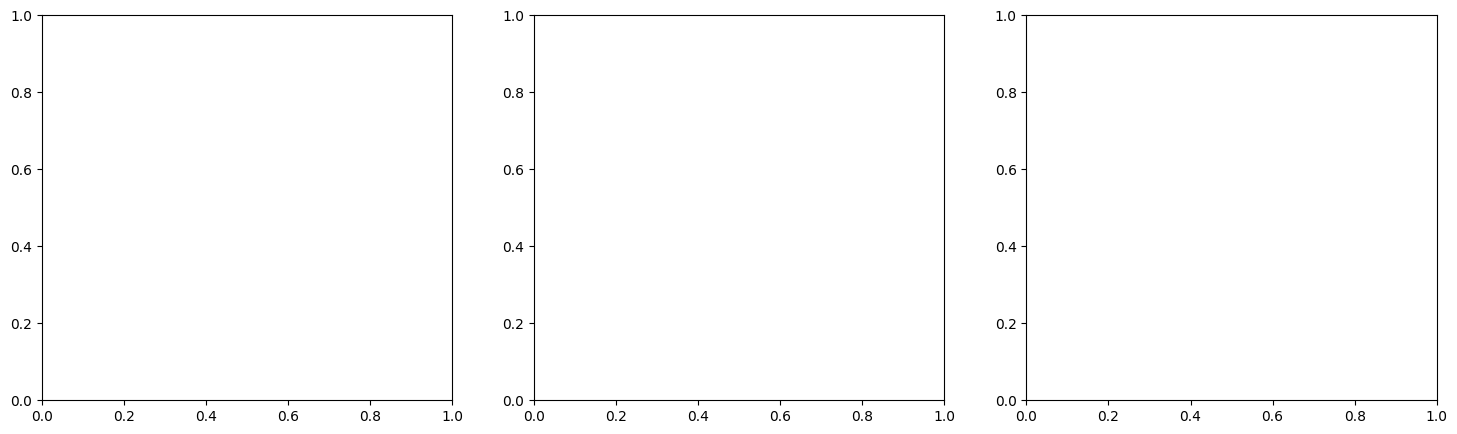

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Total loss
axes[0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# BBox loss
axes[1].plot(history['train_bbox'], label='Train', marker='o', linewidth=2, color='orange')
axes[1].plot(history['val_bbox'], label='Validation', marker='s', linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Bounding Box Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Classification loss
axes[2].plot(history['train_class'], label='Train', marker='o', linewidth=2, color='green')
axes[2].plot(history['val_class'], label='Validation', marker='s', linewidth=2, color='blue')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].set_title('Classification Loss', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Visualize predictions
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    class_names = ['go', 'stop', 'warning', 'stopLeft', 'goForward', 'goLeft', 'warningLeft']
    colors = ['green', 'red', 'yellow', 'orange', 'cyan', 'blue', 'magenta']
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]
            
            # Load original image (128x128)
            row = dataset.annotations.iloc[idx]
            img_path = row['file_path']
            orig_img = Image.open(img_path).convert('RGB').resize((128, 128))
            
            # Predict
            pred_bbox, pred_class = model(image.unsqueeze(0).to(device))
            pred_bbox = pred_bbox[0].cpu().numpy()
            pred_class = torch.softmax(pred_class[0], dim=-1).cpu().numpy()
            
            # Ground truth
            axes[i, 0].imshow(orig_img)
            axes[i, 0].set_title('Ground Truth', fontsize=12, fontweight='bold')
            axes[i, 0].axis('off')
            
            cx, cy, w, h, cls = target
            x1, y1 = (cx - w/2) * 128, (cy - h/2) * 128
            rect = patches.Rectangle((x1, y1), w*128, h*128, linewidth=2, 
                                    edgecolor=colors[int(cls)], facecolor='none')
            axes[i, 0].add_patch(rect)
            axes[i, 0].text(x1, y1-3, class_names[int(cls)], 
                          color=colors[int(cls)], fontsize=10, weight='bold',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            
            # Prediction
            axes[i, 1].imshow(orig_img)
            axes[i, 1].set_title('Prediction', fontsize=12, fontweight='bold')
            axes[i, 1].axis('off')
            
            pred_cls = np.argmax(pred_class)
            confidence = np.max(pred_class)
            
            cx, cy, w, h = pred_bbox
            x1, y1 = (cx - w/2) * 128, (cy - h/2) * 128
            rect = patches.Rectangle((x1, y1), w*128, h*128, linewidth=2,
                                    edgecolor=colors[pred_cls], facecolor='none', linestyle='--')
            axes[i, 1].add_patch(rect)
            axes[i, 1].text(x1, y1-3, f'{class_names[pred_cls]} ({confidence:.2f})',
                          color=colors[pred_cls], fontsize=10, weight='bold',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Load best model and visualize
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")

visualize_predictions(model, val_dataset, num_samples=5)


RuntimeError: Error(s) in loading state_dict for ImprovedCNN:
	Missing key(s) in state_dict: "features.0.0.weight", "features.0.0.bias", "features.0.1.weight", "features.0.1.bias", "features.0.1.running_mean", "features.0.1.running_var", "features.0.3.weight", "features.0.3.bias", "features.0.4.weight", "features.0.4.bias", "features.0.4.running_mean", "features.0.4.running_var", "features.1.0.weight", "features.1.0.bias", "features.1.1.weight", "features.1.1.bias", "features.1.1.running_mean", "features.1.1.running_var", "features.1.3.weight", "features.1.3.bias", "features.1.4.weight", "features.1.4.bias", "features.1.4.running_mean", "features.1.4.running_var", "features.2.0.weight", "features.2.0.bias", "features.2.1.weight", "features.2.1.bias", "features.2.1.running_mean", "features.2.1.running_var", "features.2.3.weight", "features.2.3.bias", "features.2.4.weight", "features.2.4.bias", "features.2.4.running_mean", "features.2.4.running_var", "features.3.0.weight", "features.3.0.

In [17]:
# Model Architecture Summary
print("\n" + "="*60)
print("📐 MODEL ARCHITECTURE")
print("="*60)
print(model)
print("\n" + "="*60)
print("📊 LAYER DETAILS")
print("="*60)

total_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    if param.requires_grad:
        trainable_params += num_params
    print(f"{name:40s} | {str(param.shape):30s} | {num_params:>10,} params")

print("="*60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")
print("="*60)



📐 MODEL ARCHITECTURE
ImprovedCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Max